# Baseline: no_aerosols_zero_wind — 3D vs 1D

Diagnostics for the **no aerosols, zero wind** baseline experiment.

| Section | Content |
|---------|---------|
| **1. LWP** | 1D vs 3D timeseries and 3D − 1D difference + integral |
| **2. Surface energy balance** | Domain-mean SEB, residual, and cloud-conditioned fluxes |
| **3. Sub-cloud turbulent flux profiles** | Cloud-root vs cloud-free absolute H/LE profiles + decomposition |


In [1]:
import sys
import os
import pickle
import warnings
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from pathlib import Path
from matplotlib.lines import Line2D

# ── path setup ────────────────────────────────────────────────────────────────
_HERE = Path.cwd()                                   # analysis/
sys.path.insert(0, str(_HERE))                       # cass_analysis, catalog
sys.path.insert(0, str(_HERE / 'cloud_roots'))       # cloud_root_composite_average

from cass_analysis import (
    load_stats, load_stats_ensemble, load_3d_nc, load_xy_files,
    RunSet,
    conditioned_means_ensemble,
    compute_normalized_cloud_root_profiles,
    plot_cloud_root_composite, COMPOSITE_VARS,
    lwp_integral, lwp_normalized_diff, _to_plottime,
    seb_residual, bowen_ratio, evaporative_fraction,
    plot_seb_timeseries, plot_seb_residual, plot_flux_conditioned,
    FLUX_COLORS, RT_STYLE, RT_LABEL,
    rho, cp, Lv,
)
from catalog import ALL_EXPERIMENTS, make_runset
from cloud_root_composite_average import average_reps


In [2]:
# ── experiment ────────────────────────────────────────────────────────────────
SCRATCH        = '/pscratch/sd/m/mpowell/CASS_LES'
EXPT_KEY       = 'no_aerosols_zero_wind'
EXPT_REL       = f'experiments/{EXPT_KEY}'
N_REPS         = 4

# ── cloud-root profile / composite config ─────────────────────────────────────
COMPOSITE_ROOT = f'{SCRATCH}/analysis/cloud_root_composite'
LST_MIN        = 10.5
LST_MAX        = 17.5
ORIENT         = 'xz'   # 'xz' or 'yz'

# ── output ────────────────────────────────────────────────────────────────────
SAVE_PDF = False   # set True to write .pdf files to the current directory

# ── RunSet (used by SEB section) ──────────────────────────────────────────────
rs = RunSet(EXPT_REL, f'{SCRATCH}/{EXPT_REL}', n_reps=N_REPS)
print(rs)

# ── CASES for cloud-root profiles / composites ────────────────────────────────
CASES = [
    dict(
        key       = '1D',
        label     = '1D (2stream)',
        run_root  = f'{SCRATCH}/{EXPT_REL}/2stream',
        comp_expt = EXPT_KEY,
        comp_rt   = '2stream',
        color     = 'C0',
    ),
    dict(
        key       = '3D',
        label     = '3D (raytracer)',
        run_root  = f'{SCRATCH}/{EXPT_REL}/raytracer',
        comp_expt = EXPT_KEY,
        comp_rt   = 'raytracer',
        color     = 'C1',
    ),
]

# ── CONDITIONS for aerosol/wind comparison (Section 5) ───────────────────────
CONDITIONS = [
    ('base',                  'C4'),
    ('no_aerosols',           'C0'),
    ('no_aerosols_zero_wind', 'C1'),
]

print('Config loaded.')


RunSet('experiments/no_aerosols_zero_wind', root=/pscratch/sd/m/mpowell/CASS_LES/experiments/no_aerosols_zero_wind)
  2stream: 4 rep(s)
  raytracer: 4 rep(s)
Config loaded.


In [3]:
# ── LWP loading ───────────────────────────────────────────────────────────────
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    rs_lwp  = make_runset(EXPT_KEY, n_reps=N_REPS)
    dirs_2s = rs_lwp.dirs.get('2stream', [])
    dirs_rt = rs_lwp.dirs.get('raytracer', [])

reps_2s  = [load_stats(d) for d in dirs_2s]
reps_rt  = [load_stats(d) for d in dirs_rt]
n_paired = min(len(reps_2s), len(reps_rt))
nt       = min(*(s['qlqi_path'].shape[0] for s in reps_2s + reps_rt))

lwp_1d_reps = np.stack([s['qlqi_path'][:nt] * 1e3 for s in reps_2s[:n_paired]])
lwp_3d_reps = np.stack([s['qlqi_path'][:nt] * 1e3 for s in reps_rt[:n_paired]])
diff_reps   = lwp_3d_reps - lwp_1d_reps

lwp_1d     = lwp_1d_reps.mean(axis=0)
lwp_3d     = lwp_3d_reps.mean(axis=0)
lwp_1d_std = lwp_1d_reps.std(axis=0, ddof=0)
lwp_3d_std = lwp_3d_reps.std(axis=0, ddof=0)
diff       = diff_reps.mean(axis=0)
diff_std   = diff_reps.std(axis=0, ddof=0)

t_local = reps_2s[0]['t_local'][:nt]
t_sec   = reps_2s[0]['t_sec'][:nt]
dt_s    = float(t_sec[1] - t_sec[0]) if len(t_sec) > 1 else 60.0

cloudy_mask  = (lwp_1d > 0.1) | (lwp_3d > 0.1)
integral     = lwp_integral(diff, dt_s, cloudy_mask=cloudy_mask)
integral_std = float(np.std(
    [lwp_integral(diff_reps[r], dt_s, cloudy_mask=cloudy_mask) for r in range(n_paired)],
    ddof=0))

print(f'LWP loaded:  n_paired={n_paired},  nt={nt}')
print(f'Cloudy-period integral: {integral:+.2f} ± {integral_std:.2f} g m⁻² h')


LWP loaded:  n_paired=4,  nt=167
Cloudy-period integral: +25.27 ± 0.93 g m⁻² h


## 1. LWP


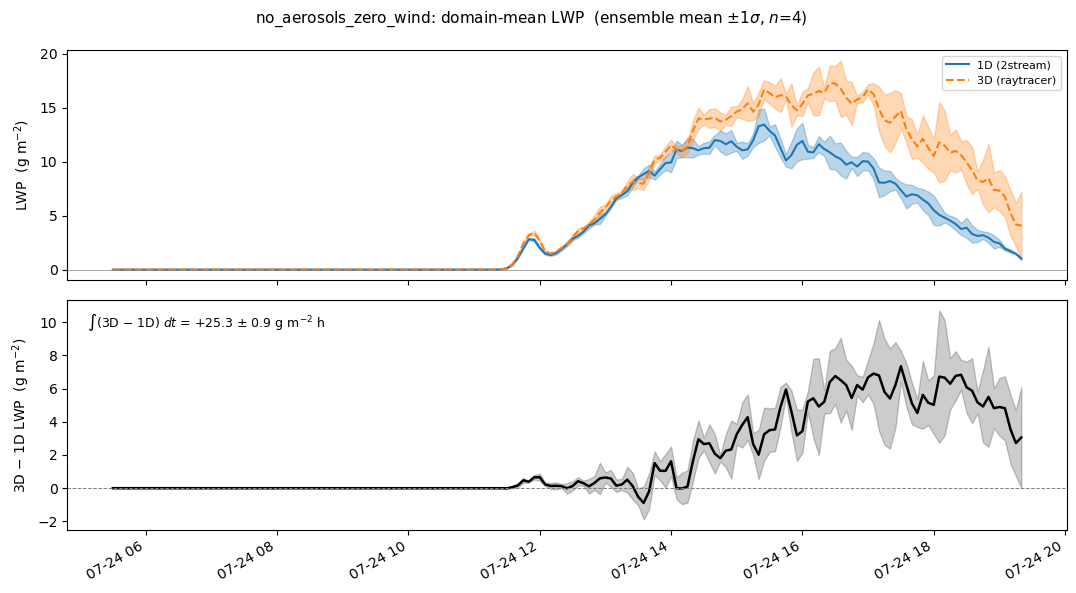

In [4]:
# ── Figure 1: LWP 1D vs 3D (top) + 3D − 1D difference (bottom) ───────────────
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
t_num = _to_plottime(t_local)

ax = axes[0]
ax.plot(t_num, lwp_1d, color='C0', lw=1.5, label='1D (2stream)')
ax.fill_between(t_num, lwp_1d - lwp_1d_std, lwp_1d + lwp_1d_std, color='C0', alpha=0.3)
ax.plot(t_num, lwp_3d, color='C1', lw=1.5, ls='--', label='3D (raytracer)')
ax.fill_between(t_num, lwp_3d - lwp_3d_std, lwp_3d + lwp_3d_std, color='C1', alpha=0.3)
ax.set_ylabel(r'LWP  (g m$^{-2}$)')
ax.axhline(0, color='gray', lw=0.5)
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(t_num, diff, color='k', lw=1.8)
ax.fill_between(t_num, diff - diff_std, diff + diff_std, color='k', alpha=0.2)
ax.axhline(0, color='gray', lw=0.7, ls='--')
ax.set_ylabel(r'3D $-$ 1D LWP  (g m$^{-2}$)')
ax.text(0.02, 0.95,
        fr'$\int$(3D $-$ 1D) $dt$ = {integral:+.1f} $\pm$ {integral_std:.1f} g m$^{{-2}}$ h',
        transform=ax.transAxes, fontsize=9, va='top')
ax.xaxis_date()
fig.autofmt_xdate()

fig.suptitle(
    fr'{EXPT_KEY}: domain-mean LWP  (ensemble mean $\pm1\sigma$, $n$={n_paired})',
    fontsize=11,
)
plt.tight_layout()
if SAVE_PDF:
    plt.savefig('lwp_baseline.pdf', bbox_inches='tight')
    print('Saved lwp_baseline.pdf')
plt.show()


## 2. Surface energy balance


In [5]:
# ── SEB: load ensemble stats ──────────────────────────────────────────────────
s2s_mean, s2s_std = load_stats_ensemble(rs.dirs['2stream'])
srt_mean, srt_std = load_stats_ensemble(rs.dirs['raytracer'])

print(f"2stream:   {len(rs.dirs['2stream'])} rep(s),  "
      f"t = {s2s_mean['t_local'][0]} → {s2s_mean['t_local'][-1]}")
print(f"raytracer: {len(rs.dirs['raytracer'])} rep(s),  "
      f"t = {srt_mean['t_local'][0]} → {srt_mean['t_local'][-1]}")

# ── SEB: load conditioned means (pickle cache) ────────────────────────────────
_SEB_CACHE = (Path(os.environ.get('SCRATCH', f'/pscratch/sd/m/mpowell'))
              / 'CASS_LES/analysis/seb_cache')
_SEB_CACHE.mkdir(parents=True, exist_ok=True)

def _compute_cond(result):
    mean_d, std_d = result
    for d in (mean_d, std_d):
        for kind in d:
            d[kind] = {var: da.compute() for var, da in d[kind].items()}
    return mean_d, std_d

def _load_or_compute_conditioned(rep_dirs, cache_name, variables, force=False):
    cache_file = _SEB_CACHE / f'{cache_name}.pkl'
    if not force and cache_file.exists():
        print(f'  [cache hit] {cache_file.name}')
        with open(cache_file, 'rb') as fh:
            return pickle.load(fh)
    print(f'  [computing] {cache_name} …')
    result = _compute_cond(conditioned_means_ensemble(rep_dirs, variables=variables))
    with open(cache_file, 'wb') as fh:
        pickle.dump(result, fh)
    print(f'  [cached]    {cache_file.name}')
    return result

_slug = EXPT_REL.replace('/', '_')
cond_2s_mean, cond_2s_std = _load_or_compute_conditioned(
    rs.dirs['2stream'],
    f'{_slug}__2stream',
    variables=['thl_fluxbot', 'qt_fluxbot', 'sw_flux_dn'],
)
cond_rt_mean, cond_rt_std = _load_or_compute_conditioned(
    rs.dirs['raytracer'],
    f'{_slug}__raytracer',
    variables=['thl_fluxbot', 'qt_fluxbot', 'sw_flux_sfc_rt', 'sw_flux_dn'],
)
print('Done.')


2stream:   4 rep(s),  t = 2005-07-24 05:30:00 → 2005-07-24 19:19:59.999999999
raytracer: 4 rep(s),  t = 2005-07-24 05:30:00 → 2005-07-24 19:19:59.999999999
  [cache hit] experiments_no_aerosols_zero_wind__2stream.pkl
  [cache hit] experiments_no_aerosols_zero_wind__raytracer.pkl
Done.


2stream  peak|resid|=6.4  daytime_mean|resid|=0.2 W m⁻²
raytracer  peak|resid|=11.4  daytime_mean|resid|=3.7 W m⁻²


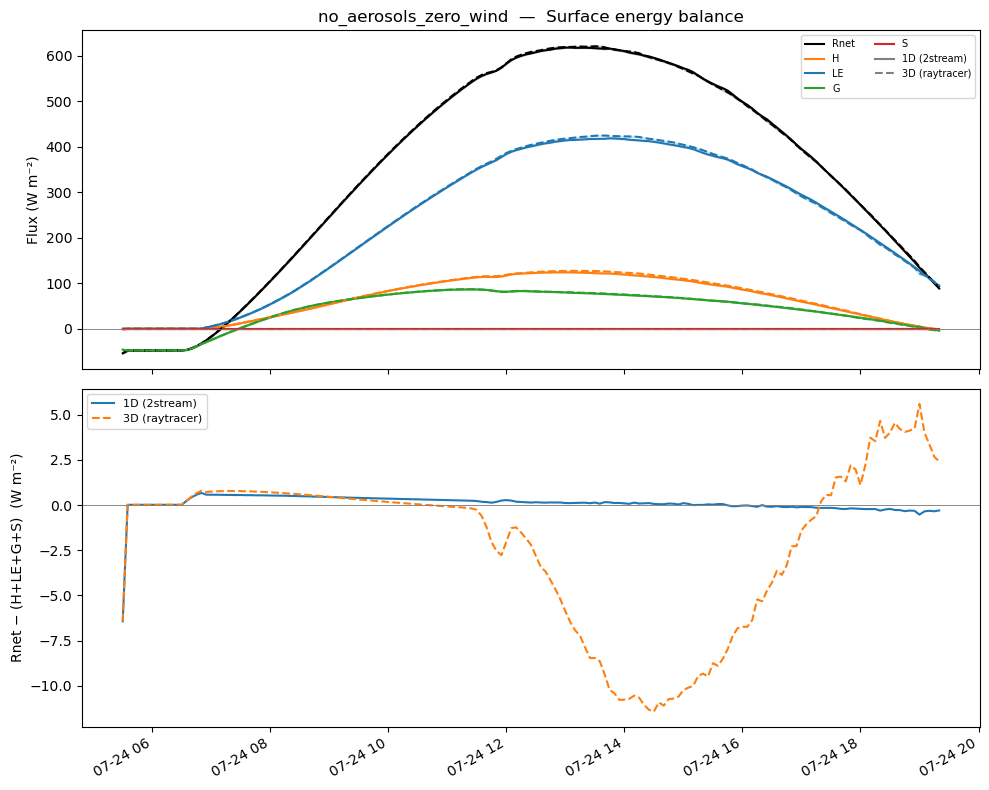

In [6]:
# ── Figure 2a: domain-mean SEB + residual ────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax = axes[0]
for rt, sm, ss in [('2stream', s2s_mean, s2s_std), ('raytracer', srt_mean, srt_std)]:
    plot_seb_timeseries(ax, sm, ss, rt_type=rt)
flux_handles = [Line2D([0],[0], color=c, ls='-', label=f) for f, c in FLUX_COLORS.items()]
rt_handles   = [Line2D([0],[0], color='gray', ls=sty['ls'], label=RT_LABEL[rt])
                for rt, sty in RT_STYLE.items()]
ax.legend(handles=flux_handles + rt_handles, fontsize=7, ncol=2)
ax.set_title(f'{EXPT_KEY}  —  Surface energy balance')

ax = axes[1]
for rt, sm in [('2stream', s2s_mean), ('raytracer', srt_mean)]:
    plot_seb_residual(ax, sm, rt_type=rt)
for rt, sm in [('2stream', s2s_mean), ('raytracer', srt_mean)]:
    resid   = seb_residual(sm)
    daytime = sm['Rnet'] > 50
    print(f'{rt}  peak|resid|={np.abs(resid).max():.1f}  '
          f'daytime_mean|resid|={np.abs(resid[daytime]).mean():.1f} W m⁻²')
ax.legend(fontsize=8)

plt.tight_layout()
if SAVE_PDF:
    plt.savefig('seb_baseline.pdf', bbox_inches='tight')
    print('Saved seb_baseline.pdf')
plt.show()


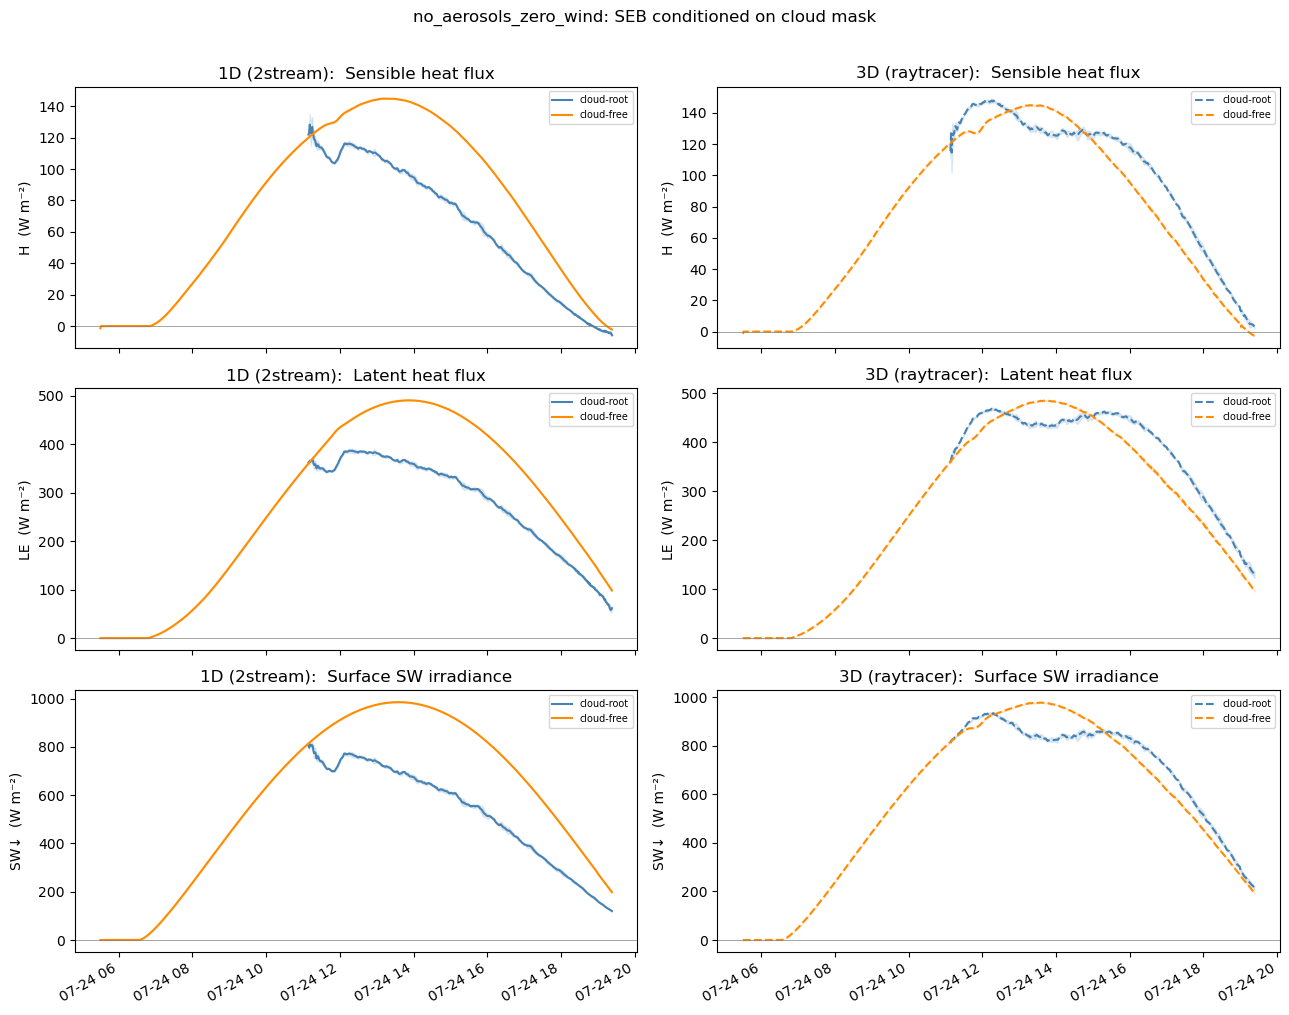

In [7]:
# ── Figure 2b: SEB conditioned on cloud mask ─────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(13, 10), sharex=True)

H_scale  = rho * cp
LE_scale = rho * Lv

for col, (rt, cm, cs) in enumerate([
    ('2stream',   cond_2s_mean, cond_2s_std),
    ('raytracer', cond_rt_mean, cond_rt_std),
]):
    t_local_c = cm['shaded']['thl_fluxbot'].time.values

    plot_flux_conditioned(
        axes[0, col], t_local_c,
        cm['shaded']['thl_fluxbot'], cm['unshaded']['thl_fluxbot'],
        cs['shaded'].get('thl_fluxbot'), cs['unshaded'].get('thl_fluxbot'),
        rt_type=rt, ylabel='H  (W m⁻²)', scale=H_scale,
    )
    axes[0, col].set_title(f'{RT_LABEL[rt]}:  Sensible heat flux')

    plot_flux_conditioned(
        axes[1, col], t_local_c,
        cm['shaded']['qt_fluxbot'], cm['unshaded']['qt_fluxbot'],
        cs['shaded'].get('qt_fluxbot'), cs['unshaded'].get('qt_fluxbot'),
        rt_type=rt, ylabel='LE  (W m⁻²)', scale=LE_scale,
    )
    axes[1, col].set_title(f'{RT_LABEL[rt]}:  Latent heat flux')

    sw_key = 'sw_flux_sfc_rt' if 'sw_flux_sfc_rt' in cm['shaded'] else 'sw_flux_dn'
    plot_flux_conditioned(
        axes[2, col], t_local_c,
        cm['shaded'][sw_key], cm['unshaded'][sw_key],
        cs['shaded'].get(sw_key), cs['unshaded'].get(sw_key),
        rt_type=rt, ylabel='SW↓  (W m⁻²)', scale=1.0,
    )
    axes[2, col].set_title(f'{RT_LABEL[rt]}:  Surface SW irradiance')

for ax in axes.flat:
    ax.legend(fontsize=7)

plt.suptitle(f'{EXPT_KEY}: SEB conditioned on cloud mask', y=1.01)
plt.tight_layout()
if SAVE_PDF:
    plt.savefig('seb_conditioned_baseline.pdf', bbox_inches='tight')
    print('Saved seb_conditioned_baseline.pdf')
plt.show()


## 3. Sub-cloud turbulent flux profiles

Reads the cloud-root cache built by `cloud_roots/free_vs_nudge_cloud_roots.ipynb` (Section A).  
Run that notebook first if the cache does not exist.


In [8]:
# ── Physical constants ────────────────────────────────────────────────────────
_RHO   = 1.2
_CP    = 1005.0
_LV    = 2.5e6
RHO_CP = _RHO * _CP
RHO_LV = _RHO * _LV * 1e-3


def load_absolute_profiles(case, n_reps=N_REPS, lst_min=LST_MIN, lst_max=LST_MAX):
    """Load cached raw flux profiles and convert to H / LE in W m⁻².
    Cache must exist — run Section A of cloud_roots/free_vs_nudge_cloud_roots.ipynb first.
    """
    H_dom_reps, H_root_reps, H_free_reps   = [], [], []
    LE_dom_reps, LE_root_reps, LE_free_reps = [], [], []
    zeta = None

    for i in range(1, n_reps + 1):
        cache_path = (Path(COMPOSITE_ROOT) / case['comp_expt'] / case['comp_rt']
                      / f'rep_{i:02d}' / 'raw_flux_profile_cache.nc')
        if not cache_path.exists():
            print(f'  SKIP {case["key"]} rep_{i:02d}: cache not found')
            continue
        ds_c = xr.open_dataset(str(cache_path))
        if 'f_free_thl' not in ds_c or 't_hours' not in ds_c:
            ds_c.close()
            print(f'  SKIP {case["key"]} rep_{i:02d}: cache outdated')
            continue

        zeta   = ds_c['zeta'].values
        t_hrs  = ds_c['t_hours'].values
        mask_t = (t_hrs >= lst_min) & (t_hrs <= lst_max)

        if mask_t.sum() == 0:
            ds_c.close()
            continue

        H_dom_reps.append( np.nanmean(ds_c['f_domain_thl'].values[mask_t] * RHO_CP, axis=0))
        H_root_reps.append(np.nanmean(ds_c['f_cloud_thl'].values[mask_t]  * RHO_CP, axis=0))
        H_free_reps.append(np.nanmean(ds_c['f_free_thl'].values[mask_t]   * RHO_CP, axis=0))
        LE_dom_reps.append( np.nanmean(ds_c['f_domain_qv'].values[mask_t] * RHO_LV, axis=0))
        LE_root_reps.append(np.nanmean(ds_c['f_cloud_qv'].values[mask_t]  * RHO_LV, axis=0))
        LE_free_reps.append(np.nanmean(ds_c['f_free_qv'].values[mask_t]   * RHO_LV, axis=0))
        ds_c.close()

    def _s(lst): return np.stack(lst) if lst else np.empty((0,))
    return dict(zeta=zeta, n_reps=len(H_dom_reps),
                H_dom=_s(H_dom_reps),   H_root=_s(H_root_reps),  H_free=_s(H_free_reps),
                LE_dom=_s(LE_dom_reps), LE_root=_s(LE_root_reps), LE_free=_s(LE_free_reps))


def load_cloud_frac(case, n_reps=N_REPS, lst_min=LST_MIN, lst_max=LST_MAX):
    """Time-mean cloud-root area fraction per rep."""
    fracs = []
    for i in range(1, n_reps + 1):
        cache_path = (Path(COMPOSITE_ROOT) / case['comp_expt'] / case['comp_rt']
                      / f'rep_{i:02d}' / 'raw_flux_profile_cache.nc')
        if not cache_path.exists():
            continue
        ds_c = xr.open_dataset(str(cache_path))
        if 'cloud_frac' not in ds_c or 't_hours' not in ds_c:
            ds_c.close()
            continue
        t_hrs  = ds_c['t_hours'].values
        mask_t = (t_hrs >= lst_min) & (t_hrs <= lst_max)
        if mask_t.sum() > 0:
            fracs.append(float(np.nanmean(ds_c['cloud_frac'].values[mask_t])))
        ds_c.close()
    return np.array(fracs)


# ── Load ──────────────────────────────────────────────────────────────────────
abs_profiles = {}
for case in CASES:
    print(f'{case["label"]} ... ', end='', flush=True)
    abs_profiles[case['key']] = load_absolute_profiles(case)
    print(f'{abs_profiles[case["key"]]["n_reps"]} reps')

cloud_fracs = {c['key']: load_cloud_frac(c) for c in CASES}
print('\nCloud-root area fraction  (mean ± 1σ)')
for key, fracs in cloud_fracs.items():
    if len(fracs) > 0:
        mu = fracs.mean()
        sd = fracs.std(ddof=1) if len(fracs) > 1 else 0.0
        print(f'  {key:6s}  α = {mu:.3f} ± {sd:.3f}  ({100*mu:.1f}%)')


1D (2stream) ... 4 reps
3D (raytracer) ... 4 reps

Cloud-root area fraction  (mean ± 1σ)
  1D      α = 0.112 ± 0.001  (11.2%)
  3D      α = 0.115 ± 0.001  (11.5%)


/tmp/ipykernel_456855/4278466427.py:37: RuntimeWarning: Mean of empty slice
  H_dom_reps.append( np.nanmean(ds_c['f_domain_thl'].values[mask_t] * RHO_CP, axis=0))
/tmp/ipykernel_456855/4278466427.py:38: RuntimeWarning: Mean of empty slice
  H_root_reps.append(np.nanmean(ds_c['f_cloud_thl'].values[mask_t]  * RHO_CP, axis=0))
/tmp/ipykernel_456855/4278466427.py:39: RuntimeWarning: Mean of empty slice
  H_free_reps.append(np.nanmean(ds_c['f_free_thl'].values[mask_t]   * RHO_CP, axis=0))
/tmp/ipykernel_456855/4278466427.py:40: RuntimeWarning: Mean of empty slice
  LE_dom_reps.append( np.nanmean(ds_c['f_domain_qv'].values[mask_t] * RHO_LV, axis=0))
/tmp/ipykernel_456855/4278466427.py:41: RuntimeWarning: Mean of empty slice
  LE_root_reps.append(np.nanmean(ds_c['f_cloud_qv'].values[mask_t]  * RHO_LV, axis=0))
/tmp/ipykernel_456855/4278466427.py:42: RuntimeWarning: Mean of empty slice
  LE_free_reps.append(np.nanmean(ds_c['f_free_qv'].values[mask_t]   * RHO_LV, axis=0))
/tmp/ipykernel_456855/

/tmp/ipykernel_456855/2093360525.py:26: RuntimeWarning: Mean of empty slice
  mu  = np.nanmean(arr, axis=0)


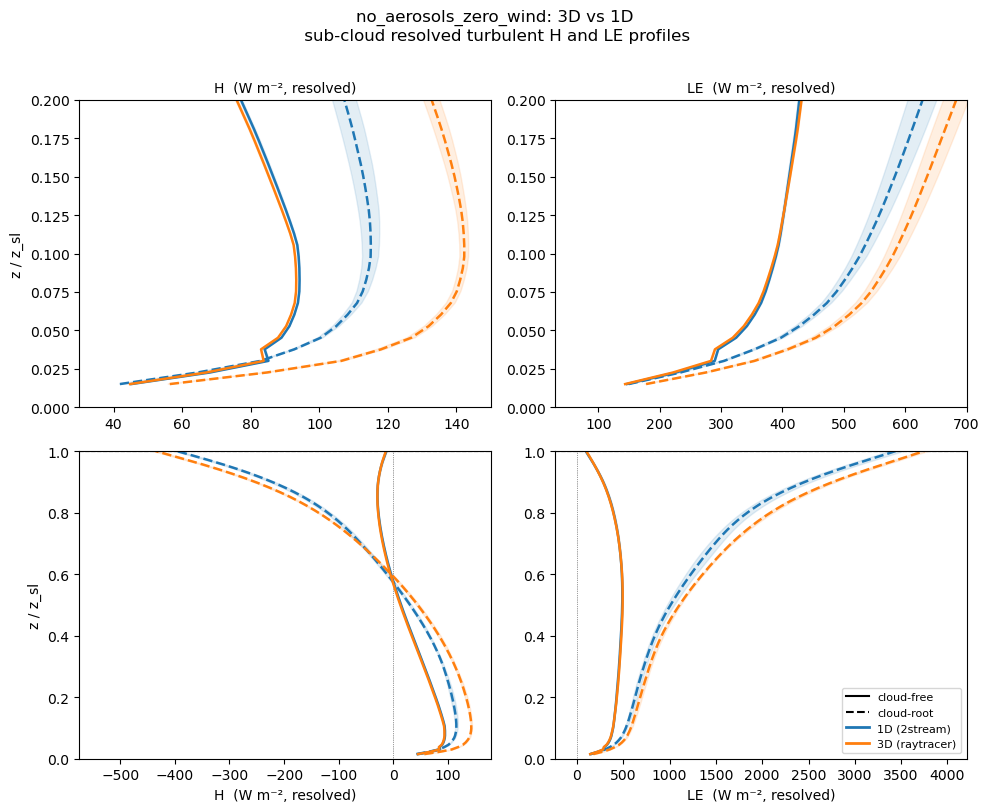

In [10]:
# ── Figure 3a: absolute flux profiles — cloud-root vs cloud-free ──────────────
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

_CONDS_ABS = [
    ('H_root', 'LE_root', 'cloud-root', '--'),
    ('H_free', 'LE_free', 'cloud-free', '-'),
]

for case in CASES:
    ap = abs_profiles[case['key']]
    for col, var in enumerate(['H', 'LE']):
        for row in range(2):
            ax = axes[row, col]
            ax.axhline(1.0, color='gray', ls='--', lw=0.8)
            ax.axvline(0,   color='gray', ls=':',  lw=0.5)
            ax.set_ylim(0, 0.2 if row == 0 else 1.0)
            if row == 0:
                ax.set_xlim(30, 150 if var == 'H' else 700)
            if ap['n_reps'] == 0:
                ax.text(0.5, 0.5, 'no data', transform=ax.transAxes,
                        ha='center', va='center', color='gray')
                continue
            zeta = ap['zeta']
            for h_key, le_key, _, ls in _CONDS_ABS:
                arr = ap[h_key if var == 'H' else le_key]
                mu  = np.nanmean(arr, axis=0)
                sd  = np.nanstd(arr, axis=0, ddof=1) if ap['n_reps'] > 1 else np.zeros_like(mu)
                ax.plot(mu, zeta, color=case['color'], ls=ls, lw=1.8)
                ax.fill_betweenx(zeta, mu - sd, mu + sd, alpha=0.12, color=case['color'])
            if row == 0:
                ax.set_title('H  (W m⁻², resolved)' if var == 'H' else 'LE  (W m⁻², resolved)', fontsize=10)
            if row == 1:
                ax.set_xlabel('H  (W m⁻², resolved)' if var == 'H' else 'LE  (W m⁻², resolved)')
            if col == 0:
                ax.set_ylabel('z / z_sl')

legend_handles = (
    [Line2D([0],[0], color='k', ls='-',  lw=1.5, label='cloud-free'),
     Line2D([0],[0], color='k', ls='--', lw=1.5, label='cloud-root')]
    + [Line2D([0],[0], color=c['color'], lw=2, label=c['label']) for c in CASES]
)
axes[1, 1].legend(handles=legend_handles, fontsize=8, loc='lower right')
plt.suptitle(f'{EXPT_KEY}: 3D vs 1D\n sub-cloud resolved turbulent H and LE profiles', y=1.01)
plt.tight_layout()
if SAVE_PDF:
    plt.savefig('flux_profiles_baseline.pdf', bbox_inches='tight')
    print('Saved flux_profiles_baseline.pdf')
plt.show()


## 4. L&P composite cross-sections

Cloud objects with chord ≥ 1 km, 11:30–15:30 LST.  
Requires composite event files — built by `cloud_roots/free_vs_nudge_cloud_roots.ipynb` Sections A–B.


In [10]:
# ── Load composite data (both xz and yz) ─────────────────────────────────────
comp_data = {}
print('Loading composites …')
for case in CASES:
    print(f'  {case["label"]}:')
    result = average_reps(
        Path(COMPOSITE_ROOT), case['comp_expt'], case['comp_rt'],
        n_reps=N_REPS, verbose=True,
    )
    comp_data[case['key']] = result   # dict with 'xz' and/or 'yz' keys

_avail = {
    orient: {k: comp_data[k][orient] for k in comp_data if orient in comp_data[k]}
    for orient in ('xz', 'yz')
}
for orient, cases in _avail.items():
    print(f'  {orient}: {list(cases.keys())} available')


Loading composites …
  1D (2stream):


/global/u2/m/mpowell/repos/microhh/cases/cass/analysis/cloud_roots/cloud_root_composite_average.py:74: RuntimeWarning: Mean of empty slice
  rep_mean_vars[vn] = np.nanmean(arr, axis=0)   # (n_znd, n_xL)


  xz  rep_01: 146 events


/global/u2/m/mpowell/repos/microhh/cases/cass/analysis/cloud_roots/cloud_root_composite_average.py:74: RuntimeWarning: Mean of empty slice
  rep_mean_vars[vn] = np.nanmean(arr, axis=0)   # (n_znd, n_xL)


  xz  rep_02: 118 events


...

/global/u2/m/mpowell/repos/microhh/cases/cass/analysis/cloud_roots/cloud_root_composite_average.py:93: RuntimeWarning: Mean of empty slice
  out[f"{vn}_mean"]     = xr.DataArray(np.nanmean(stack, axis=0),
/global/homes/m/mpowell/.conda/envs/xr_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/global/u2/m/mpowell/repos/microhh/cases/cass/analysis/cloud_roots/cloud_root_composite_average.py:74: RuntimeWarning: Mean of empty slice
  rep_mean_vars[vn] = np.nanmean(arr, axis=0)   # (n_znd, n_xL)


  yz  rep_01: 131 events


/global/u2/m/mpowell/repos/microhh/cases/cass/analysis/cloud_roots/cloud_root_composite_average.py:74: RuntimeWarning: Mean of empty slice
  rep_mean_vars[vn] = np.nanmean(arr, axis=0)   # (n_znd, n_xL)
/global/u2/m/mpowell/repos/microhh/cases/cass/analysis/cloud_roots/cloud_root_composite_average.py:74: RuntimeWarning: Mean of empty slice
  rep_mean_vars[vn] = np.nanmean(arr, axis=0)   # (n_znd, n_xL)


  yz  rep_02: 125 events
  yz  rep_03: 148 events
  yz  rep_04: 140 events
  xz: ['1D', '3D'] available
  yz: ['1D', '3D'] available


/global/u2/m/mpowell/repos/microhh/cases/cass/analysis/cloud_roots/cloud_root_composite_average.py:74: RuntimeWarning: Mean of empty slice
  rep_mean_vars[vn] = np.nanmean(arr, axis=0)   # (n_znd, n_xL)
/global/u2/m/mpowell/repos/microhh/cases/cass/analysis/cloud_roots/cloud_root_composite_average.py:93: RuntimeWarning: Mean of empty slice
  out[f"{vn}_mean"]     = xr.DataArray(np.nanmean(stack, axis=0),
/global/homes/m/mpowell/.conda/envs/xr_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


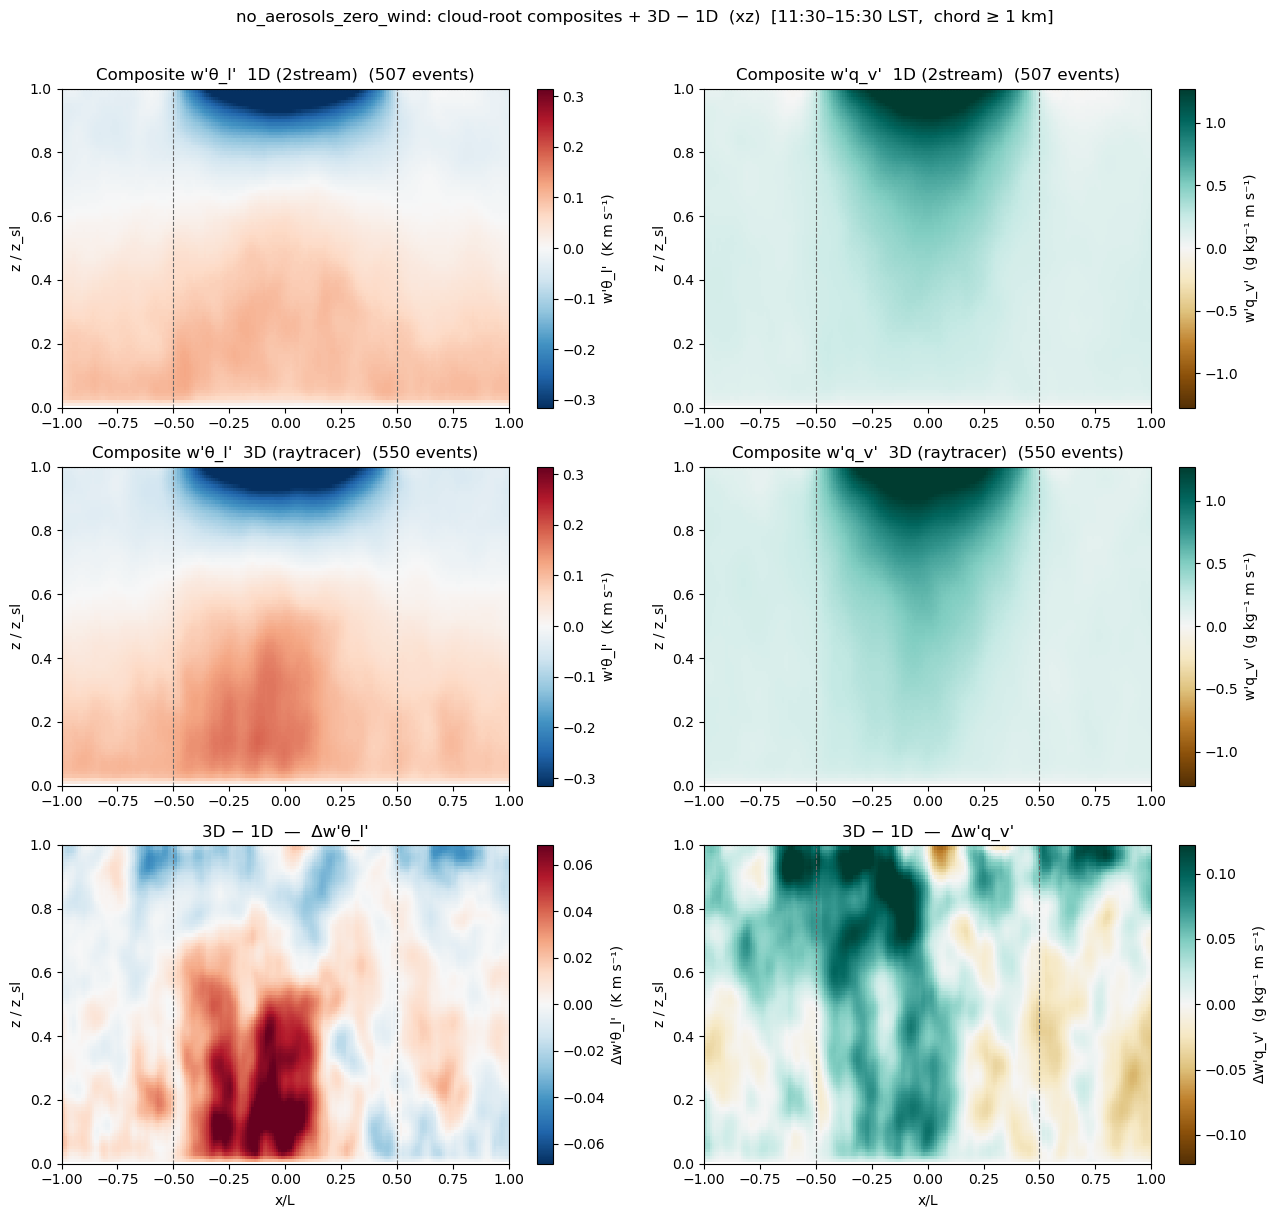

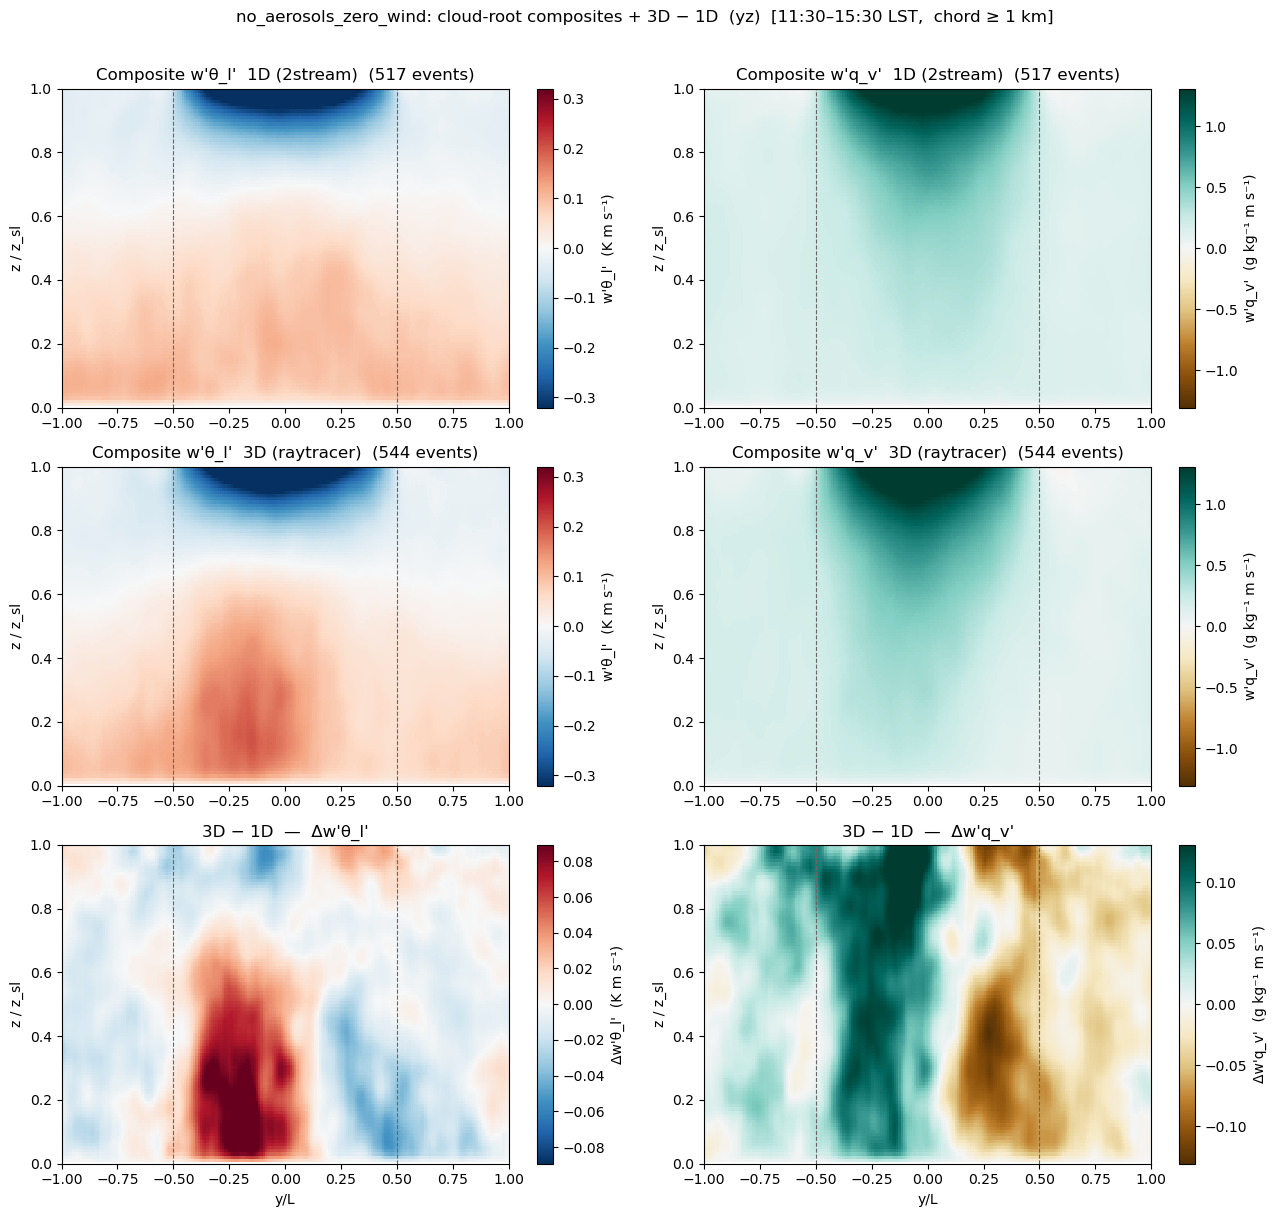

In [11]:
def _plot_composite_figure(avail_orient, orient):
    """Draw composite figure for one orientation (xz or yz).

    Rows: 1D, 3D, then 3D−1D diff (if both available).
    Only the bottom row gets an x/L or y/L label.
    """
    if not avail_orient:
        print(f'No {orient} composite data — skipping.')
        return

    def _collect(vn):
        return np.concatenate([ds[vn].values.ravel() for ds in avail_orient.values()])

    vmax_thl = float(np.nanpercentile(np.abs(_collect('w_thl_mean')), 98))
    vmax_qv  = float(np.nanpercentile(np.abs(_collect('w_qv_mean')),  98))
    vlim_thl = (-vmax_thl, vmax_thl)
    vlim_qv  = (-vmax_qv,  vmax_qv)

    _plot_rows = [c for c in CASES if c['key'] in avail_orient]
    _has_diff  = '1D' in avail_orient and '3D' in avail_orient
    n_rows     = len(_plot_rows) + (1 if _has_diff else 0)

    fig, axes = plt.subplots(n_rows, 2, figsize=(13, 4 * n_rows))
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    for row, case in enumerate(_plot_rows):
        is_bottom = (row == n_rows - 1)
        plot_cloud_root_composite(
            axes[row, 0], axes[row, 1],
            avail_orient[case['key']],
            vlim_thl=vlim_thl, vlim_qv=vlim_qv,
            label=case['label'],
            show_xlabel=is_bottom,
            orient=orient,
        )

    if _has_diff:
        row   = len(_plot_rows)   # always the bottom row
        ds_3d = avail_orient['3D']
        ds_1d = avail_orient['1D']
        xL    = ds_3d.xL.values
        z_nd  = ds_3d.z_nd.values
        hl    = 'x/L' if orient == 'xz' else 'y/L'

        for col, (var, cmap, clabel) in enumerate([
            ('w_thl_mean', 'RdBu_r', "Δw'θ_l'  (K m s⁻¹)"),
            ('w_qv_mean',  'BrBG',   "Δw'q_v'  (g kg⁻¹ m s⁻¹)"),
        ]):
            ax   = axes[row, col]
            diff = ds_3d[var].values - ds_1d[var].values
            vmax = float(np.nanpercentile(np.abs(diff), 98))
            pcm  = ax.pcolormesh(xL, z_nd, diff, cmap=cmap, shading='auto',
                                  vmin=-vmax, vmax=vmax)
            plt.colorbar(pcm, ax=ax, label=clabel)
            ax.axvline(-0.5, color='0.4', lw=0.8, ls='--')
            ax.axvline( 0.5, color='0.4', lw=0.8, ls='--')
            ax.axhline( 1.0, color='0.4', lw=0.8, ls=':')
            ax.set_xlabel(hl)          # always shown — this IS the bottom row
            ax.set_ylabel('z / z_sl')
            ax.set_xlim(-1, 1)
            ax.set_ylim(0, 1.0)
            ax.set_title(f"3D − 1D  —  {clabel.split('(')[0].strip()}")

    plt.suptitle(
        f'{EXPT_KEY}: cloud-root composites + 3D − 1D  ({orient})  '
        '[11:30–15:30 LST,  chord ≥ 1 km]',
        y=1.01,
    )
    plt.tight_layout()
    if SAVE_PDF:
        fname = f'composites_baseline_{orient}.pdf'
        plt.savefig(fname, bbox_inches='tight')
        print(f'Saved {fname}')
    plt.show()


_plot_composite_figure(_avail['xz'], 'xz')
_plot_composite_figure(_avail['yz'], 'yz')


## 5. Aerosol / wind comparison — 3D − 1D LWP

Compares three conditions (base, no aerosols, no aerosols + zero wind).


In [12]:
# ── Load LWP for all conditions ───────────────────────────────────────────────
cond_results = []

for key, color in CONDITIONS:
    meta = ALL_EXPERIMENTS[key]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        rs_c    = make_runset(key, n_reps=N_REPS)
        d_2s    = rs_c.dirs.get('2stream', [])
        d_rt    = rs_c.dirs.get('raytracer', [])

    if not d_2s or not d_rt:
        print(f'  [{key}] missing reps, skipping')
        continue

    r2s = [load_stats(d) for d in d_2s]
    rrt = [load_stats(d) for d in d_rt]
    np_ = min(len(r2s), len(rrt))
    nt_ = min(*(s['qlqi_path'].shape[0] for s in r2s + rrt))

    l1 = np.stack([s['qlqi_path'][:nt_] * 1e3 for s in r2s[:np_]])
    l3 = np.stack([s['qlqi_path'][:nt_] * 1e3 for s in rrt[:np_]])
    dr = l3 - l1

    tl_  = r2s[0]['t_local'][:nt_]
    ts_  = r2s[0]['t_sec'][:nt_]
    dt_  = float(ts_[1] - ts_[0]) if len(ts_) > 1 else 60.0
    cm_  = (l1.mean(axis=0) > 0.1) | (l3.mean(axis=0) > 0.1)

    intg = lwp_integral(dr.mean(axis=0), dt_, cloudy_mask=cm_) if cm_.any() else np.nan
    istd = float(np.std([lwp_integral(dr[r], dt_, cloudy_mask=cm_) for r in range(np_)], ddof=0)) if cm_.any() else np.nan

    cond_results.append(dict(
        key=key, label=meta['label'], color=color,
        t_local=tl_,
        lwp_1d=l1.mean(axis=0),  lwp_1d_std=l1.std(axis=0, ddof=0),
        lwp_3d=l3.mean(axis=0),  lwp_3d_std=l3.std(axis=0, ddof=0),
        diff=dr.mean(axis=0),     diff_std=dr.std(axis=0, ddof=0),
        integral=intg, integral_std=istd, n_paired=np_,
    ))
    int_s = f'{intg:+.2f} ± {istd:.2f} g m⁻² h' if not np.isnan(intg) else 'n/a'
    print(f'{key:30s}  integral = {int_s}')

print(f'\n{len(cond_results)} conditions loaded.')


base                            integral = +0.52 ± 0.25 g m⁻² h
no_aerosols                     integral = +13.68 ± 0.41 g m⁻² h
no_aerosols_zero_wind           integral = +25.27 ± 0.93 g m⁻² h

3 conditions loaded.


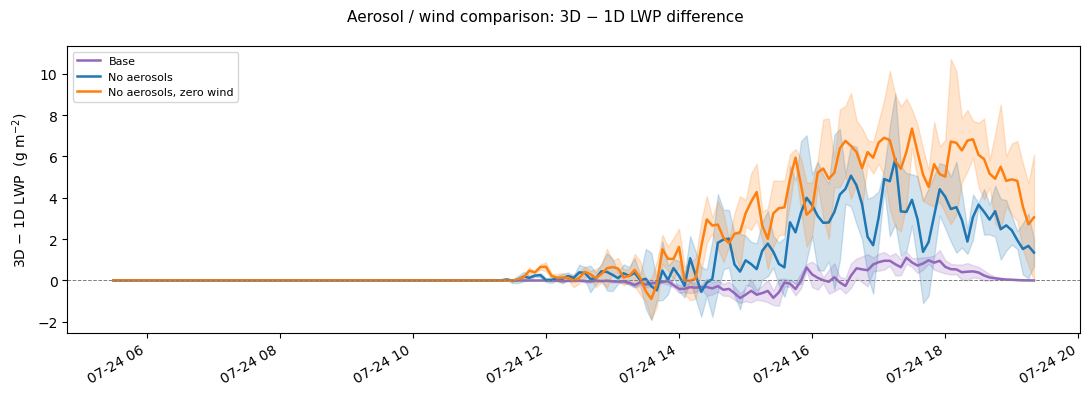

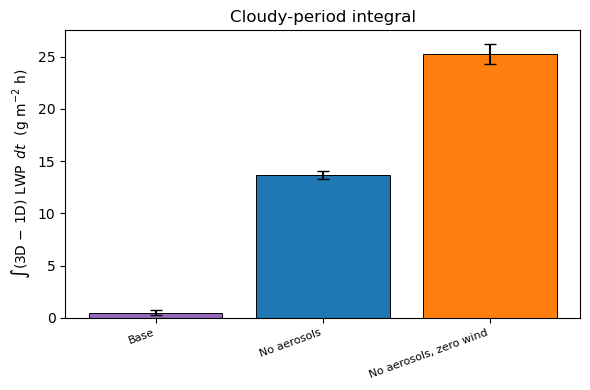

In [13]:
# ── Figure 5a: 3D − 1D diff timeseries, all conditions overlaid ───────────────
fig, ax = plt.subplots(figsize=(11, 4))
for r in cond_results:
    t_num = _to_plottime(r['t_local'])
    ax.plot(t_num, r['diff'], color=r['color'], lw=1.8, label=r['label'])
    ax.fill_between(t_num, r['diff'] - r['diff_std'], r['diff'] + r['diff_std'],
                    color=r['color'], alpha=0.2)
ax.axhline(0, color='gray', lw=0.7, ls='--')
ax.set_ylabel(r'3D $-$ 1D LWP  (g m$^{-2}$)')
ax.legend(fontsize=8)
ax.xaxis_date()
fig.autofmt_xdate()
fig.suptitle('Aerosol / wind comparison: 3D − 1D LWP difference', fontsize=11)
plt.tight_layout()
if SAVE_PDF:
    plt.savefig('lwp_comparison_diff.pdf', bbox_inches='tight')
    print('Saved lwp_comparison_diff.pdf')
plt.show()

# ── Figure 5b: integral bar chart ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
x_pos = np.arange(len(cond_results))
for x, r in zip(x_pos, cond_results):
    if np.isnan(r['integral']):
        ax.bar(x, 0, color=r['color'], edgecolor='k', lw=0.7, hatch='//', alpha=0.4)
        ax.text(x, 0.01, 'no clouds', ha='center', va='bottom', fontsize=7, style='italic')
    else:
        ax.bar(x, r['integral'], color=r['color'], edgecolor='k', lw=0.7)
        ax.errorbar(x, r['integral'], yerr=r['integral_std'],
                    fmt='none', color='k', capsize=4, lw=1.5)
ax.axhline(0, color='gray', lw=0.7)
ax.set_xticks(x_pos)
ax.set_xticklabels([r['label'] for r in cond_results], fontsize=8, rotation=20, ha='right')
ax.set_ylabel(r'$\int$(3D $-$ 1D) LWP $\,dt$  (g m$^{-2}$ h)')
ax.set_title('Cloudy-period integral')
plt.tight_layout()
if SAVE_PDF:
    plt.savefig('lwp_comparison_integral.pdf', bbox_inches='tight')
    print('Saved lwp_comparison_integral.pdf')
plt.show()


In [27]:
import xarray as xr
import matplotlib.pyplot as plt

In [ ]:
ds_rt = xr.open_dataset("/pscratch/sd/m/mpowell/CASS_LES/experiments/no_aerosols_zero_wind/raytracer/rep_01/qlqi_path.xy.nc", decode_times = False)
ds_1D = xr.open_dataset("/pscratch/sd/m/mpowell/CASS_LES/experiments/no_aerosols_zero_wind/2stream/rep_01/qlqi_path.xy.nc", decode_times = False)

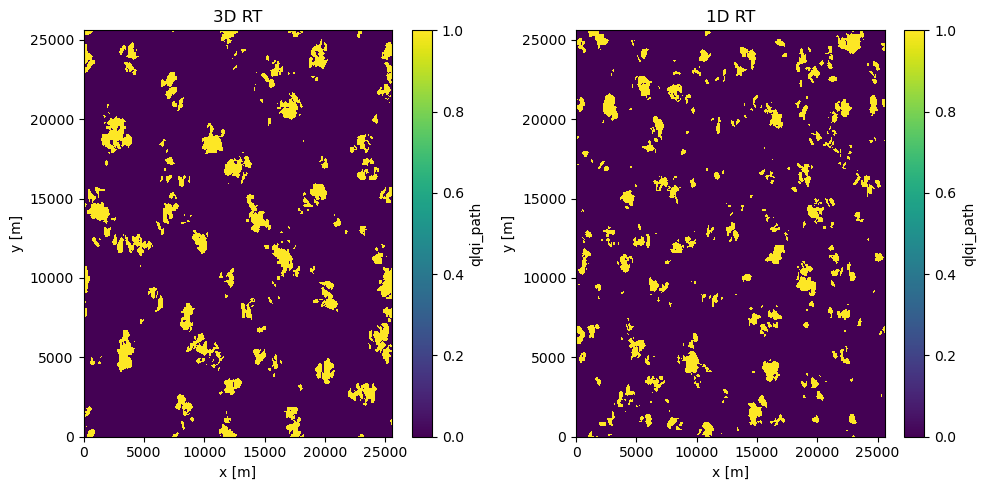

In [34]:
fig, axs = plt.subplots(1, 2, figsize =  (10, 5))
(ds_rt.isel(time = -100).qlqi_path > 0.001).plot(ax = axs[0])
axs[0].set_title("3D RT")
(ds_1D.isel(time = -100).qlqi_path > 0.001).plot(ax = axs[1])
axs[1].set_title("1D RT")
plt.tight_layout()